# Sampling and inference

This notebook builds the M1 functional-response model (`../scripts/model.py`), runs
structural and prior-predictive checks, samples the posterior, checks convergence,
computes the posterior contrasts used to confirm or deny the claims in Nandini et al.
(2026), checks prior sensitivity on the flagged parameters, builds the bounded-support
alternative M2, and compares M1 against M2 by LOO-CV.

**Model status.** M1 -- a Holling type-II disc equation with attack rate and handling
time each carrying a `{prey, salinity, interaction}` structure, and a two-component
(process + measurement) Gamma likelihood -- uses the maximum-entropy priors elicited in
`01_prior_elicitation.ipynb` (the `build_model` defaults in `model.py` already reflect
this; see that module's docstring for the individual prior derivations). An earlier
structural baseline (M0, known-SE-only likelihood) was used only to confirm the
mechanistic structure sampled cleanly before the process-error term was added, and is
not part of this notebook. M2 (a Beta likelihood on the proportion consumed, addressing
a ceiling-violation gap in M1's prior predictive distribution) is built and compared
against M1 later in this notebook (see *Model comparison: M1 vs M2*).

**What this notebook does NOT yet cover:** `phi`, M2's dispersion parameter, has not
been elicited from background knowledge in the manner of M1's priors and is used here
as a placeholder (see `build_model_m2`'s docstring). A prior-width sensitivity sweep was
run on the salinity main effect and the prey x salinity interaction on attack rate
(flagged by `psense`); the equivalent check was not run for handling time's flagged
parameters.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import pymc as pm
import matplotlib.pyplot as pp

import arviz_plots as azp
import arviz_stats as azs

sys.path.append(str(Path.cwd().parent /"scripts"))
from model import build_model, build_model_m2
from plot_utils import two_panel_dag, render_forest, render_prior_posterior
from stats_utils import (
    reconstruct_mechanistic_parameters, expected_eaten, compare, named_contrast_dataset,
    summarize_ppc, summarize_contrasts, summarize_prior_posterior)


## Data and setup

In [3]:
PROJ_DIR = Path.cwd().parent
FIG_DIR = PROJ_DIR / 'figures'
DATA_DIR = PROJ_DIR / "data"
SENT_DAT_DIR = DATA_DIR / "sent_data"
PROC_DAT_DIR = SENT_DAT_DIR / "processed"
ART_DIR = PROJ_DIR / 'artifacts'

In [4]:
# --> Load aggregated functional response data
# --> This data was used to build figure 2 in Nandini et al (2026)

fr = pd.read_csv(PROC_DAT_DIR / 'hoja1_functional_response.csv')


In [5]:
SAL_LEVELS = [10, 20, 30]
N0   = fr['N0'].to_numpy(float)
ybar = fr['mean_consumed'].to_numpy(float)
se   = fr['se_consumed'].to_numpy(float)


In [6]:
prey_idx, prey = pd.factorize(fr['Prey_Type'])
prey_idx = prey_idx.astype('int32')
# Salinity is ordinal, so we'll proceed differently
sal_int = fr['Salinity'].str.extract(r'(\d+)')[0].astype(int)
sal_idx = pd.Categorical(
    sal_int, categories=SAL_LEVELS, ordered=True
    ).codes.astype('int32')

assert (prey_idx >= 0).all(), "NaN/unmapped prey slipped to -1"
assert (sal_idx  >= 0).all(), "salinity label outside {10, 20, 30}"
assert len(prey) == 3, f"expected 3 prey, got {list(prey)}"

coords = {
    "prey": list(prey),
    "salinity": SAL_LEVELS,
    "obs": np.arange(len(fr)),
    }


## Generative model

Holling disc equation:
$$\mu =  \frac{\alpha \cdot N}{1+\alpha \cdot h \cdot N}$$
where,
* $\alpha$ is attack rate
* $h$ is handling time
* $N$ is prey density offered

The data generative process can be represented as follows:

<u>Indexing</u>:
* $i \in \{1, 2, 3\}$ - prey (Apo, Nito, Bp)
* $j \in \{1, 2, 3\}$ - salinity (10, 20, 30 g/L)
* $k = K_{ij}$ - series of initial prey density offered
* $u$, $v$ - prey ($i$), salinity ($j$) main effect, respectively (for $\alpha$ and $h$)
* $w$ - prey $\times$ salinity interaction ($ij$) for both $\alpha$ and $h$
* $\alpha_{ij}$ - attack rate (low-density capture fraction) per cell
* $h_{ij}$ - handling time, per cell
* $N_{0,ijk}$ - offered prey density (data)
* $\mu_{ijk}$ - mean consumption, via $\mu=\frac{\alpha N_0}{1 + \alpha h N_0}$
* $A_{ij} = 1 / h_{ij}$ - asymptote, the maximum-consumption number for reporting

**Cell-level mechanistic parameters** (one $\alpha_{ij}$ and one $h_{ij}$ per
prey$\times$salinity cell -- no $k$ dependence, since attack rate $\alpha$ and
handling time $h$ are Holling constants across prey density):

$$logit(\alpha_{ij}) = a_0 + u_i^a + v_j^a + w_{ij}^a, \ \ \alpha_{ij} = logit^{-1}(\cdot)\in (0,1)$$

$$log(h_{ij}) = h_0 + u_i^h + v_j^h + w_{ij}^h, \ \ h_{ij} = exp(\cdot) > 0$$

Holling mean; density $k$ enters here and only here:

$$\mu_{ijk} = \frac{\alpha_{ij} \cdot N_{0,ijk}}{1+\alpha_{ij} \cdot h_{ij} \cdot N_{0,ijk}}$$

Likelihood:
$$\bar{y}_{ijk} \sim Gamma(\mu=\mu_{ijk}, \sigma=\sigma_{\text{eff},ijk}), \ \ \sigma_{\text{eff},ijk} = \sqrt{\tau^2 + se_{ijk}^2}$$

## Model background

**Design variables, set by the experimenter:** salinity $S$, prey type $P$, prey
density $N_0$. Because these are intervened on, the DAG has no arrows *into* them: no
backdoor paths, so each effect on the parameters and outcome is a clean causal effect
by design.

**Latent Holling parameters:** attack rate $\alpha$ (low-density capture fraction) and
handling time $h$. These are the mechanistic quantities of the Type II functional
response ([Holling 1959](https://doi.org/10.4039/Ent91385-7)). A Type II response is
documented in other cnidarians, e.g. the cold-water coral *Desmophyllum dianthus*
([H&ouml;fer et al. 2018](https://doi.org/10.7717/peerj.5872)) -- which notably showed
**non-saturation** at high prey density, mirroring the weak asymptote identifiability
we meet here -- and the source study reports a Type II response for *C. caspia* itself.

**Why a functional-response model.** *C. caspia* is an invasive predator, and
comparative functional-response analysis is an established framework for predicting
invader impact from attack rate and handling time
([Dick et al. 2014](https://doi.org/10.1007/s10530-013-0550-8)).

**Prey type &rarr; &alpha;, h (direct morphology effect).** Prey identity sets size,
escape speed, and exoskeleton, which govern both capture and processing. *Cordylophora*
recognises and captures prey by chemoreception of proline/protease cues, discharging
nematocysts ([Fulton 1963](https://doi.org/10.1085/jgp.46.4.823)); larger, faster, or
better-armoured prey are captured and handled differently. Small prey size is a
documented anti-predator defence that lowers effective attack rate for invertebrate
predators (Sarma & Nandini 2007; see Nandini et al. 2026 and refs therein), consistent
with rotifers being taken at a lower fraction than copepods.

**Holling assembly and the (0, N0) bound.** `mu = alpha*N0 / (1 + alpha*h*N0)`: at low
density `mu -> alpha*N0` (capture-limited, slope alpha); at high density `mu -> 1/h`
(handling-limited asymptote `A`). Since `alpha` is in (0,1) and the denominator >= 1,
`mu < N0` **by construction**. Note this bounds the *mean* `mu`, not a simulated
observation -- addressing that gap in a simulated draw is the motivation for the
bounded-support model M2, built and compared against M1 later in this notebook (see
*M2: bounded-support alternative* and *Model comparison: M1 vs M2*).

## Measurement model: two-variance (process + measurement) error

M1's measurement layer restores the process/lack-of-fit term that measurement-error
models carry: a true value scatters around the structural prediction (process SD
`tau`, estimated), and the observation scatters around the true value (measurement SD,
the known `se`). Marginalising the latent true mean over Gaussians gives the quadrature
`sigma_eff = sqrt(tau^2 + se^2)` -- so `tau` is the process sigma and `se` the known
measurement scale
([McElreath 2023, PyMC port, Lecture 17](https://www.pymc.io/projects/examples/en/latest/statistical_rethinking_lectures/17-Measurement_and_Misclassification.html)).

### Salinity &rarr; &alpha; and h (via unobserved osmotic states)

- **S &rarr; predator state &rarr; &alpha;, h.** Salinity gates the capture apparatus
  directly: *C. caspia* nematocysts cease to function in freshwater and its feeding
  reaction is salinity-dependent ([Fulton 1963](https://doi.org/10.1085/jgp.46.4.823)).
  Salinity also imposes osmotic stress on the hydroid at the tissue/cellular level --
  cell shrinkage/lysis, volume-regulation cost -- altering growth and hydranth
  morphology ([Folino-Rorem & Renken 2018](https://doi.org/10.1111/ivb.12207)). A
  stressed or morphologically altered polyp plausibly captures (&alpha;) and processes
  (h) prey differently.
- **S &rarr; prey state &rarr; &alpha;, h.** Salinity osmotically stresses the
  euryhaline prey too, changing rigidity/behaviour and thus catchability and subdual
  time. Because the tested prey tolerate 10-30 g/L, this prey-side effect is expected
  to be **modest** -- one reason h's priors are deliberately tighter.
- **Unobserved mediators &rArr; total effect only.** Both osmotic-state nodes are
  unmeasured, so the model estimates the **total** salinity effect on &alpha; and h;
  it cannot separate prey-mediated from predator-mediated routes. Stated limitation,
  not a bug.

### Prey &times; salinity interaction

Prey type and salinity share the prey-osmotic-state child, so their effects on
&alpha; and h are non-additive by construction. This is not mere speculation: the
source ANOVA found a **significant salinity &times; prey interaction on prey numbers**
(Nandini et al. 2026, Table 2: salinity p = 0.036, prey p = 0.006, interaction p = 0.018).

### A literature tension we address rather than hide

The source paper's narrative concludes "salinities ranging from 10 to 30 g/L had no
effect on the predator's feeding behavior," and its *biomass* ANOVA shows no salinity
main effect (p = 0.256) or interaction (p = 0.650). At face value that argues against
routing salinity into &alpha; and h. We proceed for four reasons:

1. **The tension is with the biomass/summary framing, not the counts.** The same
   study's *numbers* ANOVA shows significant salinity and salinity&times;prey effects
   (Table 2, above). Our response is counts, so salinity structure is consistent with
   the data's own count-level result.
2. **Causal structure is set by mechanism, then regularised by priors -- not pruned by
   data.** A path that plausibly generates the data belongs in the graph; the data
   update it (McElreath, Lecture 17). Deleting salinity because one ANOVA was
   non-significant would let a null dictate the causal model.
3. **A non-significant frequentist effect is not zero.** The model returns a posterior
   per salinity contrast with honest uncertainty; where the data are uninformative
   (especially for h/asymptote), power-scaling sensitivity (`psense`) will flag the
   effect as prior-driven rather than silently assuming it away.
4. **Euryhaline biology predicts small, not absent.** Predator and prey both tolerate
   the tested range, so we *expect* modest effects -- encoded as tighter h priors, not
   a deleted path.

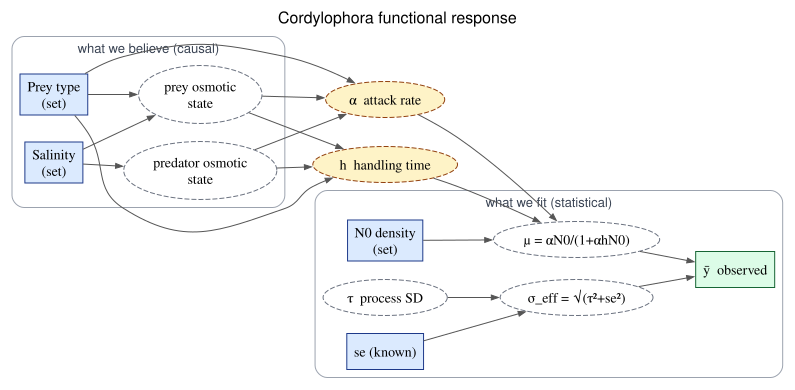

In [7]:
two_panel_dag("M1")   # renders inline; causal + statistical structure of M1

In [8]:
two_panel_dag("M1").render(FIG_DIR/'m1_dag', format="pdf", cleanup=True)

'/Users/erdemkarakoylu/projex/replications/nandini_et_al/figures/m1_dag.pdf'

In [9]:
two_panel_dag("M1").render(FIG_DIR/'m1_dag', format="png", cleanup=True)

'/Users/erdemkarakoylu/projex/replications/nandini_et_al/figures/m1_dag.png'

## Build the model

`build_model`'s keyword defaults (`a_sal_sigma`, `a_int_sigma`, and every other prior
baked into the function body) are the maximum-entropy priors elicited in
`01_prior_elicitation.ipynb`, not placeholders -- see `model.py`'s docstring for the
derivation of each. The `a_sal_sigma=...`/`a_int_sigma=...` overrides used later in this
notebook (prior-sensitivity sweeps) are deliberate departures from these defaults for
that specific diagnostic purpose, not a sign the defaults themselves are provisional.

In [10]:
fr_model = build_model(
    coords=coords, N0=N0, ybar=ybar, se=se, prey_idx=prey_idx, sal_idx=sal_idx
)

## Structural checks

Confirm the model graph is wired as intended and that the log-probability evaluates
cleanly at the initial point, before spending any sampling time.

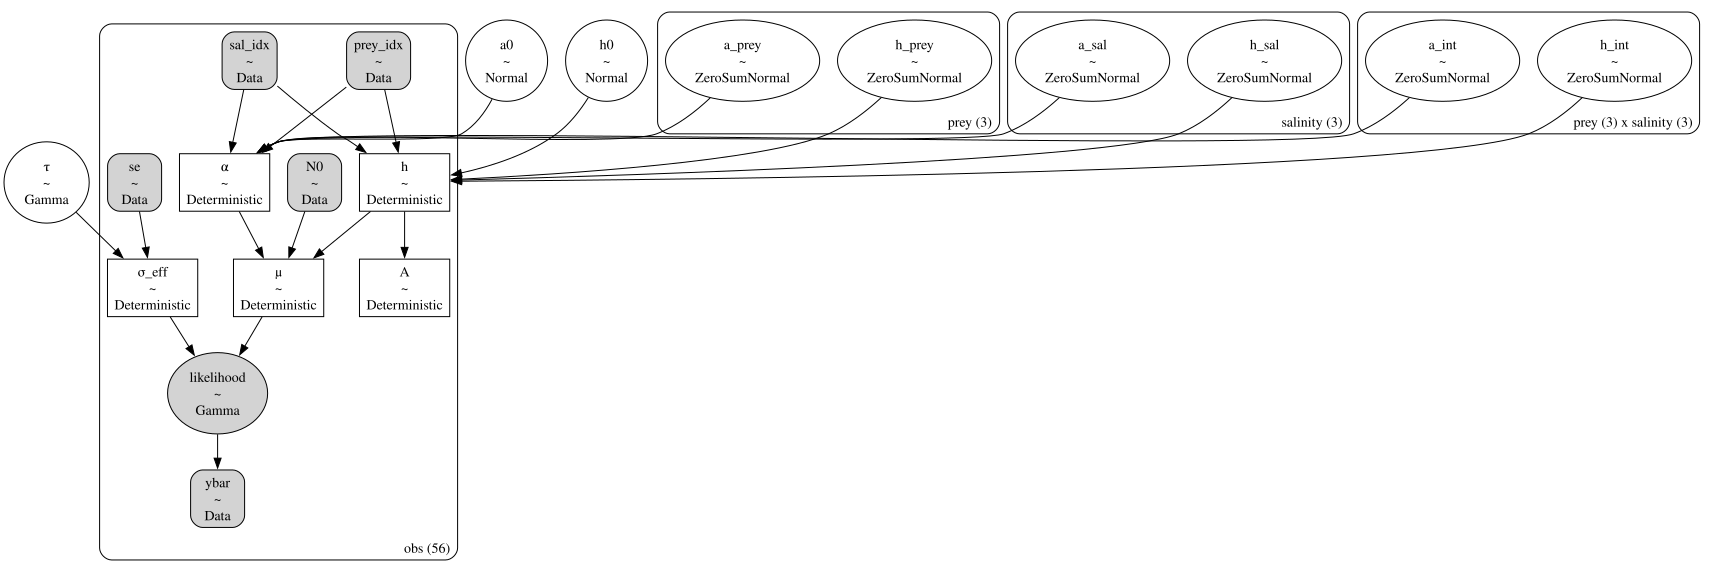

In [11]:
fr_model.to_graphviz()

In [12]:
fr_model.debug()

point={'a0': array(0.), 'a_prey_zerosum__': array([0., 0.]), 'a_sal_zerosum__': array([0., 0.]), 'a_int_zerosum__': array([[0., 0.],
       [0., 0.]]), 'h0': array(-3.68887945), 'h_prey_zerosum__': array([0., 0.]), 'h_sal_zerosum__': array([0., 0.]), 'h_int_zerosum__': array([[0., 0.],
       [0., 0.]]), 'τ_log__': array(0.98837646)}

No problems found


## Prior predictive check

Simulate from the priors alone (no conditioning on `ybar`) and confirm: (1) simulated
consumption is structurally sane relative to the offered density, and (2) implied
attack rates and asymptotes are biologically plausible.

In [13]:
with fr_model:
    idata = pm.sample_prior_predictive()


Sampling: [a0, a_int, a_prey, a_sal, h0, h_int, h_prey, h_sal, likelihood, τ]


In [14]:
prior_pred_y = idata.prior_predictive["likelihood"]   # (chain, draw, obs)
N0_check = idata.constant_data["N0"]                   # (obs,)

# 1) STRUCTURAL: every simulated consumption must lie in (0, N0).
#    This tests the logit+log construction, not the priors. Must be exactly 0.
over  = (prior_pred_y > N0_check).mean().item()
under = (prior_pred_y < 0).mean().item()
print(f"P(sim > N0) = {over:.4f}   P(sim < 0) = {under:.4f}")

# 2) BIOLOGICAL: implied asymptote A = 1/h should be tens of prey, not millions.
A = idata.prior["A"]
print("A (1/h) quantiles 1/50/99:", np.round(A.quantile([.01,.5,.99]).values, 1))

# while you're here, the attack rate shouldn't pile at the bounds:
a = idata.prior["\u03b1"]
print("\u03b1 quantiles 1/50/99:", np.round(a.quantile([.01,.5,.99]).values, 3))


P(sim > N0) = 0.0281   P(sim < 0) = 0.0000
A (1/h) quantiles 1/50/99: [  4.8  40.8 352.6]
α quantiles 1/50/99: [0.023 0.506 0.974]


/Users/erdemkarakoylu/miniconda3/envs/causal_marine/lib/python3.13/site-packages/arviz_plots/plots/utils_ppc.py:68: UserWarning: This plot always uses the `observed_data` group.
Be cautious when using it for prior predictive checks.
  warn_if_prior_predictive(group)


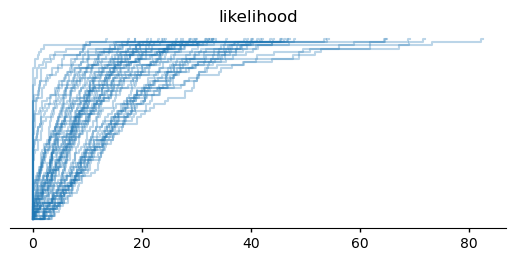

In [15]:
pc = azp.plot_ppc_dist(idata, group="prior_predictive")


## Sampling

In [16]:
with fr_model:
    idata.update(pm.sample(draws=2000))


/Users/erdemkarakoylu/miniconda3/envs/causal_marine/lib/python3.13/site-packages/arviz/__init__.py:110: MigrationWarning: arviz.InferenceData is no longer available on the arviz package; ArviZ now uses xarray's DataTree for the same role. See the migration guide: https://python.arviz.org/en/latest/user_guide/migration_guide.html#datatree
  warnings.warn(
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_54687/1577943726.py:2: UserWarning: pymc requires nutpie>=0.16.10. Falling back to the pymc NUTS sampler. Upgrade with `pip install -U nutpie` or `conda install -c conda-forge 'nutpie>=0.16.10'`.
  idata.update(pm.sample(draws=2000))
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a_prey, a_sal, a_int, h0, h_prey, h_sal, h_int, τ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


## Convergence diagnostics

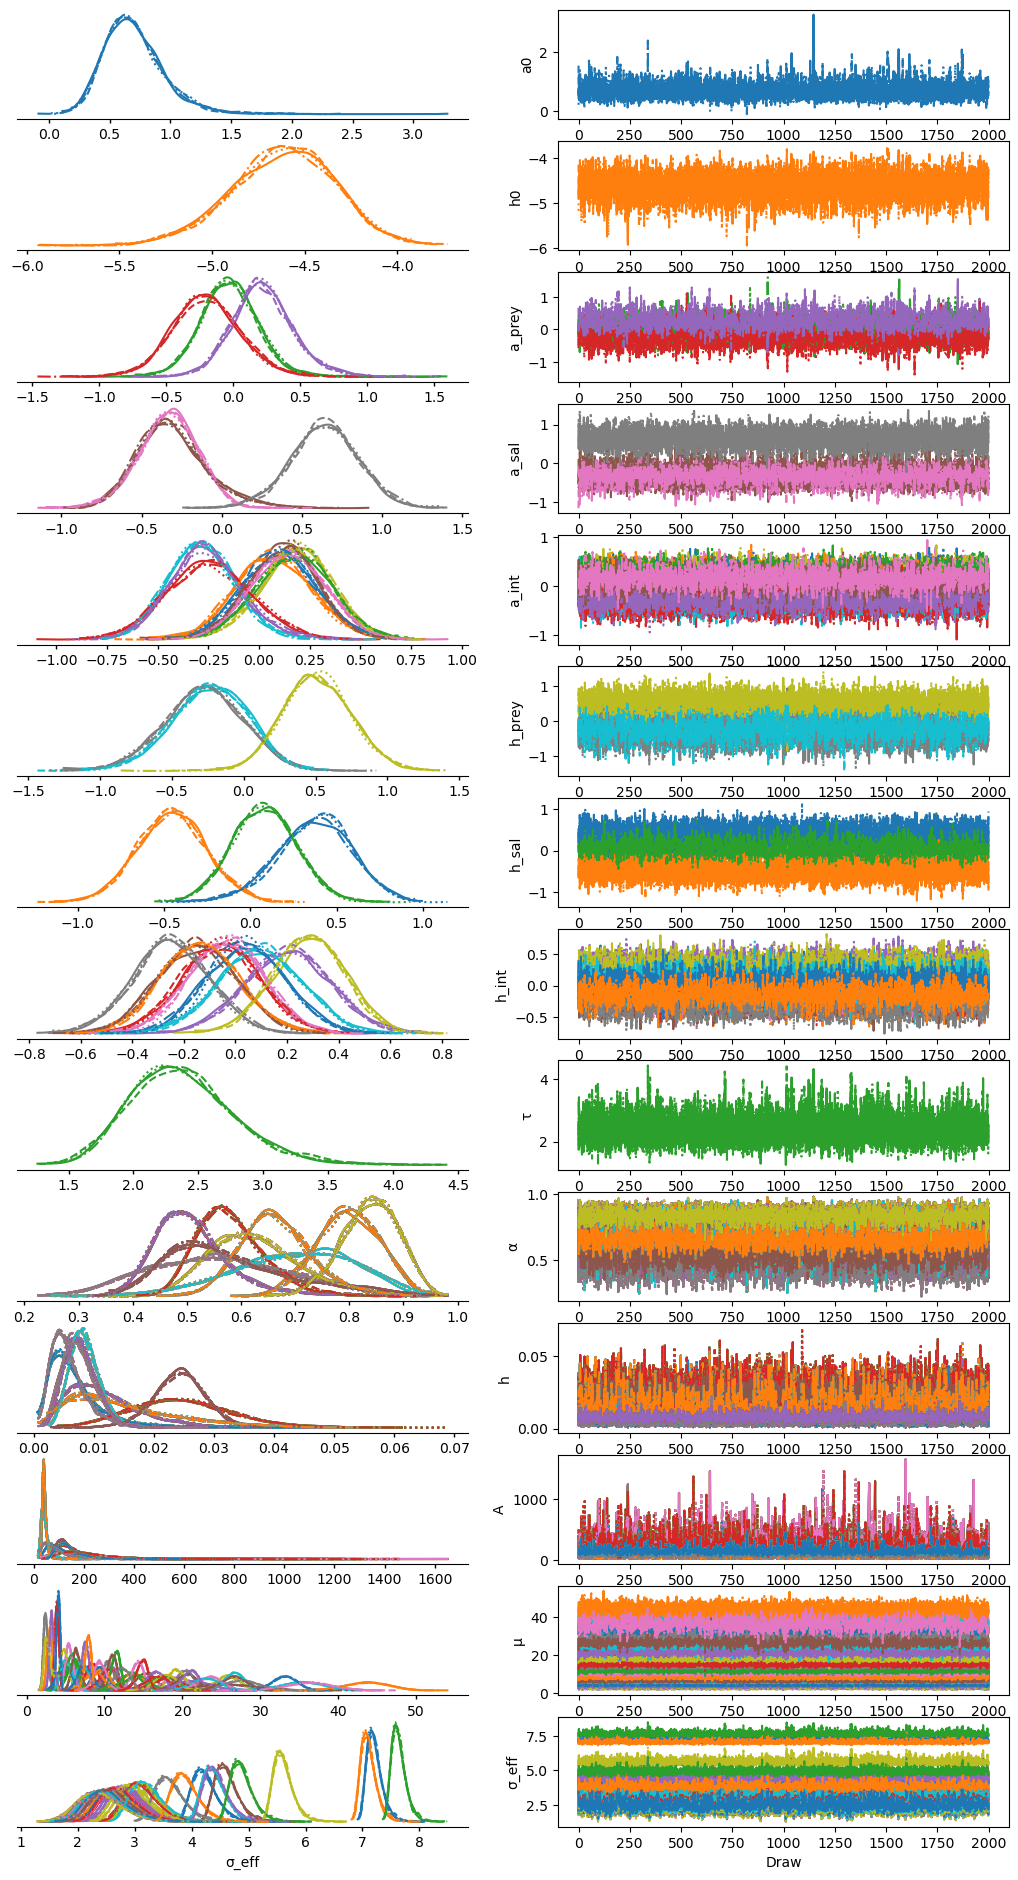

In [17]:
azp.plot_trace_dist(idata)

In [18]:
with fr_model:
    idata.update(pm.sample_posterior_predictive(idata))


Sampling: [likelihood]


Output()

{'coverage': 0.9642857142857143,
 'prob': 0.94,
 'mean_abs_error': 1.9397567458412561,
 'mean_signed_error': 0.2596118853048287}

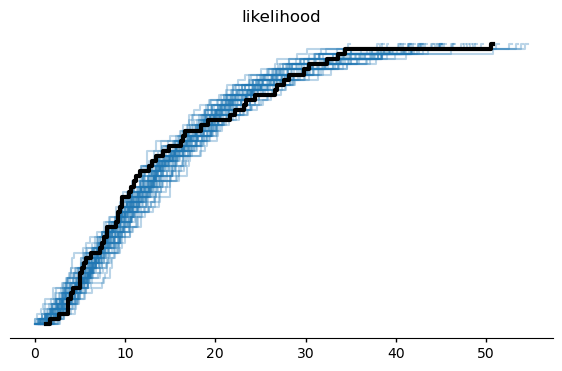

In [19]:
pc = azp.plot_ppc_dist(
    idata, group="posterior_predictive", 
    visuals={"observed_dist": {"linewidth": 3}}, figure_kwargs={"figsize": (7, 4)})
pc.savefig(FIG_DIR / "ppc.png", dpi=300, bbox_inches="tight")

summarize_ppc(idata)

### Checkpoint

Save the fitted `idata` to disk immediately after sampling and reload it, rather than
continuing to hold only the in-memory object. Sampling above is the most expensive step
in this notebook; checkpointing here means a kernel restart or later error does not
require re-sampling, and the reload is a cheap round-trip check that the saved artifact
actually contains what downstream cells expect.

In [20]:
idata.to_netcdf(ART_DIR / 'm1_idata.nc')

In [21]:
idata = xr.open_datatree(ART_DIR / 'm1_idata.nc')

In [22]:
print(idata)                      # sanity check: posterior group, var names, dims
print(list(idata.posterior.data_vars))


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:   (chain: 1, draw: 500, obs: 56, prey: 3, salinity: 3)
│       Coordinates:
│         * chain     (chain) int64 8B 0
│         * draw      (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│         * obs       (obs) int64 448B 0 1 2 3 4 5 6 7 8 ... 47 48 49 50 51 52 53 54 55
│         * prey      (prey) <U4 48B 'Apo' 'Bp' 'Nito'
│         * salinity  (salinity) int64 24B 10 20 30
│       Data variables: (12/14)
│           α         (chain, draw, obs) float64 224kB ...
│           h         (chain, draw, obs) float64 224kB ...
│           h0        (chain, draw) float64 4kB ...
│           A         (chain, draw, obs) float64 224kB ...
│           a_prey    (chain, draw, prey) float64 12kB ...
│           a_int     (chain, draw, prey, salinity) float64 36kB ...
│           ...        ...
│           h_prey    (chain, draw, prey) float64 12kB ...
│           μ         (chain, draw, obs) float64 224kB ...
│ 

In [23]:
ok, diag = azs.diagnose(idata, return_diagnostics=True, show_diagnostics=False)
print(ok)
print(diag)


False
{'divergent': {'n_divergent': 0, 'pct': np.float64(0.0), 'total_samples': np.int64(8000)}, 'treedepth': {'n_max': 0, 'pct': np.float64(0.0), 'total_samples': np.int64(8000)}, 'bfmi': {'bfmi_values': array([0.97411698, 0.99403416, 1.00448624, 0.93925998]), 'failed_chains': [], 'threshold': 0.3}, 'ess': {'bad_params': [], 'ess_values': <xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*, 'threshold_ratio': 0.001, 'total_samples': np.int64(8000)}, 'rhat': {'bad_params': [], 'rhat_values': <xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*, 'threshold': 1.01}}


## Posterior contrasts: confirming/denying Nandini et al.'s claims

1. Copepods eaten more than rotifers
2. Nitokra (harpacticoid) preferred over Apocyclops (cyclopoid)
3. Salinity makes no real difference (over the tested range)
4. Prey and salinity interact.

All reported intervals below are 94% HDIs, read directly (no region-of-practical-
equivalence threshold applied).

In [24]:
attack_rate, handling_time = reconstruct_mechanistic_parameters(idata.posterior)


### Attack rate: pairwise prey contrasts

`expected_eaten` (from `stats_utils`) is available for consumption-at-a-density
questions but is not invoked below; the contrasts here are on attack rate directly.

In [25]:
for p1, p2 in [("Nito","Apo"), ("Nito","Bp"), ("Apo","Bp")]:
    compare(attack_rate.sel(prey=p1).mean("salinity"),
            attack_rate.sel(prey=p2).mean("salinity"),
            f"{p1} vs {p2} (alpha)")


Nito vs Apo (alpha)                      mean=+0.048  94% HDI=[-0.072, +0.191]  P(a>b)=0.77
Nito vs Bp (alpha)                       mean=+0.082  94% HDI=[-0.088, +0.241]  P(a>b)=0.83
Apo vs Bp (alpha)                        mean=+0.033  94% HDI=[-0.134, +0.189]  P(a>b)=0.64


### Attack rate: pairwise salinity contrasts, and forest plot

,mean,hdi_low,hdi_high,p_gt_ref
contrast,,,,
Nito - Apo,0.048271,-0.072116,0.190610,0.771375
Nito - Bp,0.081524,-0.087636,0.241366,0.826250
Apo - Bp,0.033252,-0.133548,0.189062,0.642750
sal 10 - 30,-0.188641,-0.339727,-0.037900,0.019125
sal 10 - 20,0.003522,-0.133538,0.152841,0.495500
sal 20 - 30,-0.192163,-0.312037,-0.076334,0.003750


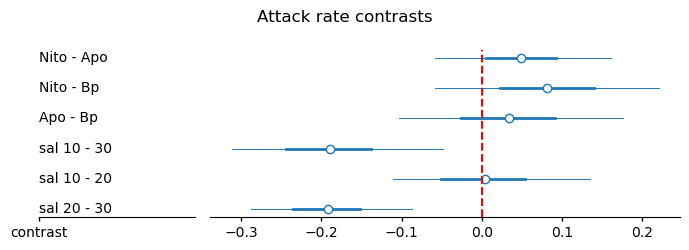

In [26]:
a_pieces = {
    "Nito - Apo":  (attack_rate.sel(prey="Nito") - attack_rate.sel(prey="Apo")).mean("salinity"),
    "Nito - Bp":   (attack_rate.sel(prey="Nito") - attack_rate.sel(prey="Bp")).mean("salinity"),
    "Apo - Bp":    (attack_rate.sel(prey="Apo")  - attack_rate.sel(prey="Bp")).mean("salinity"),
    "sal 10 - 30": (attack_rate.sel(salinity=10) - attack_rate.sel(salinity=30)).mean("prey"),
    "sal 10 - 20": (attack_rate.sel(salinity=10) - attack_rate.sel(salinity=20)).mean("prey"),
    "sal 20 - 30": (attack_rate.sel(salinity=20) - attack_rate.sel(salinity=30)).mean("prey"),
}
a_contrasts = named_contrast_dataset(a_pieces, "\u0394 attack rate")
render_forest(a_contrasts, "\u0394 attack rate", "Attack rate contrasts", ref_line=0.0,
              figsize=(7, 2.5), save_path=FIG_DIR / "forest_attack_rate.png", save_kwargs={"dpi": 300})

summarize_contrasts(a_pieces, ref=0.0)

### Attack rate: interaction contrasts

Claim 4 (does prey and salinity interact?) was previously checked only via a
prior-sensitivity sweep (see *Prior-width sweep* below), which reports the contrast at
several different `a_int_sigma` values but never at the single elicited value on the
primary fit -- so no number or figure for this claim existed outside that sweep table.
This closes that gap directly: the natural difference-in-differences quantity is
"does the 20-30 g/L attack-rate gap for this prey differ from Apocyclops's gap,"
computed here on `idata` (the primary, elicited-prior posterior), matching the same
`render_forest`/`summarize_contrasts` pattern used for the other two claims above.

,mean,hdi_low,hdi_high,p_gt_ref
contrast,,,,
(Nito gap) - (Apo gap),-0.113140,-0.284621,0.050551,0.10125
(Bp gap) - (Apo gap),-0.171509,-0.389803,0.040721,0.06150


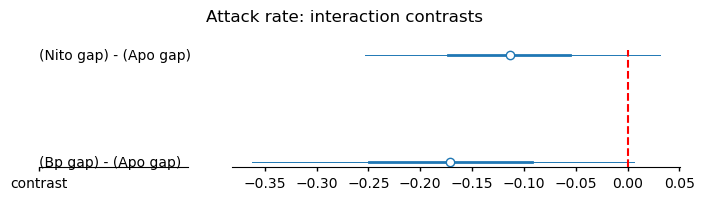

In [ ]:
gap = lambda p: attack_rate.sel(prey=p, salinity=30) - attack_rate.sel(prey=p, salinity=20)
int_pieces = {
    "(Nito gap) - (Apo gap)": gap("Nito") - gap("Apo"),
    "(Bp gap) - (Apo gap)":   gap("Bp")   - gap("Apo"),
}
int_contrasts = named_contrast_dataset(int_pieces, "Δ (20-30 gap)")
render_forest(int_contrasts, "Δ (20-30 gap)", "Attack rate: interaction contrasts", ref_line=0.0,
              figsize=(7, 2.4), save_path=FIG_DIR / "forest_interaction.png", save_kwargs={"dpi": 300})

summarize_contrasts(int_pieces, ref=0.0)


### Handling time: pairwise prey and salinity contrasts (differences and ratios)

Handling time is modeled multiplicatively (`h = exp(...)`), so raw differences are hard
to read against a small, cell-dependent baseline; both the raw difference and the
fold-change ratio are printed, and the ratio is used for the forest plot.

,mean,hdi_low,hdi_high,p_gt_ref
contrast,,,,
Nito / Apo,1.224838,0.307787,2.371234,0.568250
Nito / Bp,0.560468,0.175710,1.008021,0.053250
Apo / Bp,0.562953,0.142389,1.069004,0.072750
sal 10/30,1.510553,0.623855,2.540667,0.829750
sal 10/20,2.572908,0.960536,4.307699,0.988875
sal 20/30,0.688705,0.291467,1.174304,0.108500


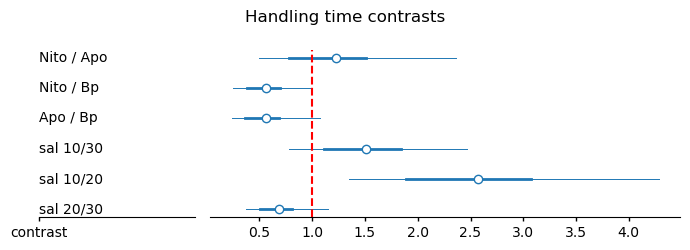

In [29]:
h_pieces = {
    "Nito / Apo": (handling_time.sel(prey="Nito") / handling_time.sel(prey="Apo")).mean("salinity"),
    "Nito / Bp":  (handling_time.sel(prey="Nito") / handling_time.sel(prey="Bp")).mean("salinity"),
    "Apo / Bp":   (handling_time.sel(prey="Apo")  / handling_time.sel(prey="Bp")).mean("salinity"),
    "sal 10/30":  (handling_time.sel(salinity=10) / handling_time.sel(salinity=30)).mean("prey"),
    "sal 10/20":  (handling_time.sel(salinity=10) / handling_time.sel(salinity=20)).mean("prey"),
    "sal 20/30":  (handling_time.sel(salinity=20) / handling_time.sel(salinity=30)).mean("prey"),
}
h_contrasts = named_contrast_dataset(h_pieces, "handling time ratio")
render_forest(h_contrasts, "handling time ratio", "Handling time contrasts", ref_line=1.0,
              figsize=(7, 2.5), save_path=FIG_DIR / "forest_handling_time.png", save_kwargs={"dpi": 300})

summarize_contrasts(h_pieces, ref=1.0)

,prior_mean,prior_sd,post_mean,post_sd,shift_in_prior_sd,sd_ratio
variable,,,,,,
h_prey[Apo],0.004517,0.405281,-0.274157,0.277624,-0.687607,0.685017
h_prey[Bp],0.016304,0.430947,0.510658,0.237322,1.147136,0.550700
h_prey[Nito],-0.020821,0.400292,-0.236501,0.265246,-0.538808,0.662630
h_sal[10],0.016974,0.248746,0.371260,0.214878,1.424290,0.863844
h_sal[20],-0.015100,0.255903,-0.453724,0.199846,-1.714025,0.780945
h_sal[30],-0.001874,0.244624,0.082464,0.186633,0.344764,0.762936
"h_int[Apo,10]",0.007789,0.172685,-0.058680,0.152948,-0.384915,0.885702
"h_int[Apo,20]",0.000598,0.171268,0.205608,0.165388,1.197012,0.965668
"h_int[Apo,30]",-0.008386,0.167558,-0.146927,0.154492,-0.826826,0.922024


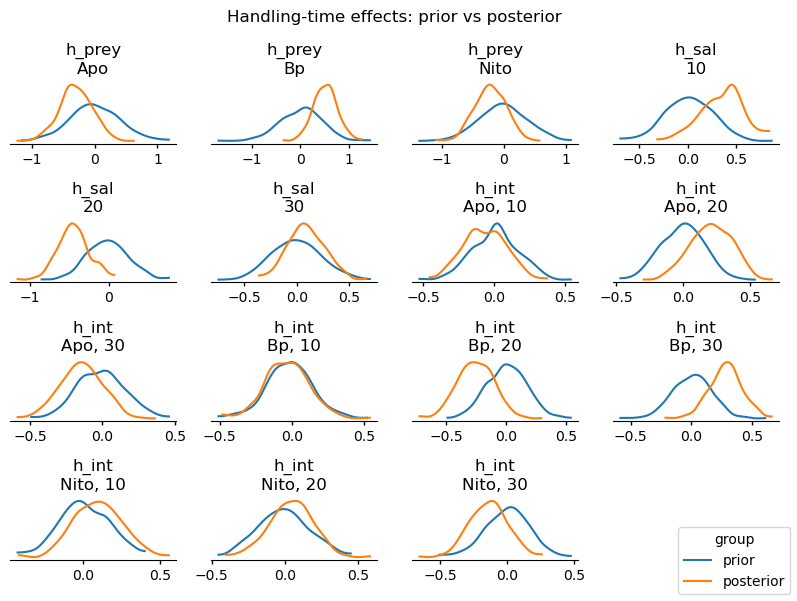

In [30]:
render_prior_posterior(idata, ["h_prey", "h_sal", "h_int"], title="Handling-time effects: prior vs posterior",
                        figsize=(8, 6), legend_loc="lower right",
                        save_path=FIG_DIR / "prior_posterior_h.png", save_kwargs={"dpi": 300})

summarize_prior_posterior(idata, ["h_prey", "h_sal", "h_int"])


## Prior sensitivity: power-scaling check

The attack-rate salinity contrast changed sign between an earlier fit (wide,
non-differentiated `a_sal` prior) and the current fit (elicited, tighter `a_sal`
prior) — see Results. Power-scaling sensitivity checks whether this posterior is
fragile to the strength of the prior (or the likelihood) without refitting: it
reweights the existing draws as if the prior/likelihood had been raised to a power
alpha (alpha<1 weakens it, alpha>1 strengthens it) via Pareto-smoothed importance
sampling, and reports the divergence (CJS) between the base and power-scaled
posteriors. CJS > 0.05 on the prior side, with the likelihood side low, flags a
conclusion that is prior-driven rather than data-driven — exactly what a sign
flip across prior choices would predict.

In [31]:
with fr_model:
    pm.stats.compute_log_likelihood(idata, model=fr_model)
    pm.compute_log_prior(idata, model=fr_model)

assert "log_likelihood" in idata.children and "log_prior" in idata.children

Output()

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_54687/3303264466.py:3: DeprecationWarning: `pymc.compute_log_prior` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.stats.compute_log_prior` instead.
  pm.compute_log_prior(idata, model=fr_model)


Output()

In [32]:
azs.psense_summary(idata, var_names=["a_sal", "a_prey", "a_int"])

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
a_sal[10],0.052,0.105,potential prior-data conflict
a_sal[20],0.159,0.221,potential prior-data conflict
a_sal[30],0.153,0.280,potential prior-data conflict
a_prey[Apo],0.028,0.126,✓
a_prey[Bp],0.027,0.118,✓
a_prey[Nito],0.043,0.100,✓
"a_int[Apo, 10]",0.077,0.133,potential prior-data conflict
"a_int[Apo, 20]",0.097,0.091,potential prior-data conflict
"a_int[Apo, 30]",0.120,0.191,potential prior-data conflict
"a_int[Bp, 10]",0.043,0.111,✓


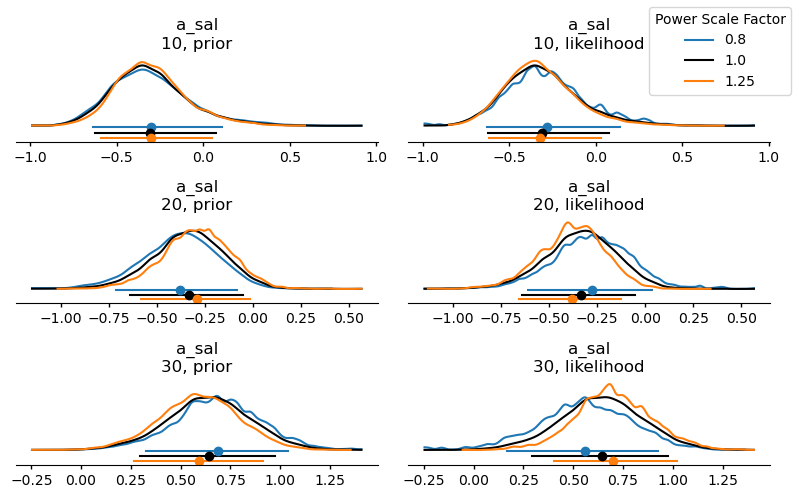

In [33]:
pc = azp.plot_psense_dist(idata, var_names=["a_sal"], figure_kwargs={"figsize": (8, 5)})
pc.viz["figure"].item().tight_layout()
pc.savefig(FIG_DIR / "psense_a_sal.png", dpi=300, bbox_inches="tight")

## Prior-width sweep: salinity and interaction

`psense` (above) flagged prior-data conflict on the salinity main effect (`a_sal`, at
20 and 30 g/L) and on the prey x salinity interaction (`a_int`, all nine cells). This
sweeps both: the salinity prior's width, checking both the 20-30 and 10-30 g/L
attack-rate contrasts; and the interaction prior's width, checking whether the 20-30
g/L salinity gap in attack rate is consistent across prey (the same derived quantity
computed on the primary fit above, now checked for stability across a range of
plausible `a_int_sigma` values rather than reported at the single elicited value).

In [34]:
sigmas = [0.20, 0.30, 0.40, 0.55, 0.70, 1.00]
rows = []
for s in sigmas:
    m_s = build_model(coords, N0, ybar, se, prey_idx, sal_idx, a_sal_sigma=s)
    with m_s:
        idata_s = pm.sample(draws=2000, tune=1000, chains=4, cores=1, progressbar=False)
    attack_rate_s, _ = reconstruct_mechanistic_parameters(idata_s.posterior)
    for label, (lvl_a, lvl_b) in [("20-30", (20, 30)), ("10-30", (10, 30))]:
        contrast = (attack_rate_s.sel(salinity=lvl_a) - attack_rate_s.sel(salinity=lvl_b)).mean("prey")
        hdi = azs.hdi(contrast, prob=0.94)
        lo, hi = float(hdi.sel(ci_bound="lower")), float(hdi.sel(ci_bound="upper"))
        p_gt = float((contrast.stack(z=("chain","draw")) > 0).mean())
        rows.append({"contrast": label, "a_sal_sigma": s, "mean": float(contrast.mean()),
                     "hdi_low": lo, "hdi_high": hi, "p_gt_0": p_gt})

pd.DataFrame(rows)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_54687/4187615387.py:6: UserWarning: pymc requires nutpie>=0.16.10. Falling back to the pymc NUTS sampler. Upgrade with `pip install -U nutpie` or `conda install -c conda-forge 'nutpie>=0.16.10'`.
  idata_s = pm.sample(draws=2000, tune=1000, chains=4, cores=1, progressbar=False)
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [a0, a_prey, a_sal, a_int, h0, h_prey, h_sal, h_int, τ]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_54687/4187615387.py:6: UserWarning: pymc requires nutpie>=0.16.10. Falling back to the pymc NUTS sampler. Upgrade with `pip install -U nutpie` or `conda install -c conda-forge 'nutpie>=0.16.10'`.
  idata_s = pm.sample(draws=2000, tune=1000, chains=4, cores=1, progressbar=False)
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chain

,contrast,a_sal_sigma,mean,hdi_low,hdi_high,p_gt_0
0,20-30,0.20,-0.088187,-0.188603,0.013759,0.055625
1,10-30,0.20,-0.081123,-0.190658,0.029152,0.087875
2,20-30,0.30,-0.149884,-0.264583,-0.039801,0.012750
3,10-30,0.30,-0.144903,-0.278464,-0.006601,0.031000
4,20-30,0.40,-0.190888,-0.304677,-0.070069,0.004500
5,10-30,0.40,-0.188396,-0.338037,-0.032583,0.019375
6,20-30,0.55,-0.227873,-0.343927,-0.103042,0.001875
7,10-30,0.55,-0.229813,-0.383966,-0.071288,0.007500
8,20-30,0.70,-0.252110,-0.373582,-0.122803,0.000750
9,10-30,0.70,-0.255328,-0.414273,-0.086674,0.006375


In [35]:
# NOTE: the a_int_sigma=0.35 row below is an INDEPENDENT REFIT at the elicited value,
# not the same posterior as the primary-fit interaction contrasts computed earlier
# (different random seed / MCMC run) -- expect close but not bit-identical agreement.
int_sigmas = [0.15, 0.25, 0.35, 0.50, 0.70]  # 0.35 = current elicited value
rows_int = []
for s in int_sigmas:
    m_s = build_model(coords, N0, ybar, se, prey_idx, sal_idx, a_int_sigma=s)
    with m_s:
        idata_s = pm.sample(draws=2000, tune=1000, chains=4, cores=1, progressbar=False)
    attack_rate_s, _ = reconstruct_mechanistic_parameters(idata_s.posterior)
    gap = lambda p: attack_rate_s.sel(prey=p, salinity=30) - attack_rate_s.sel(prey=p, salinity=20)
    for other in ["Nito", "Bp"]:
        diff_in_diff = gap(other) - gap("Apo")  # is the 20-30 gap different for this prey vs Apo?
        hdi = azs.hdi(diff_in_diff, prob=0.94)
        lo, hi = float(hdi.sel(ci_bound="lower")), float(hdi.sel(ci_bound="upper"))
        p_gt = float((diff_in_diff.stack(z=("chain","draw")) > 0).mean())
        rows_int.append({"contrast": f"({other} gap) - (Apo gap)", "a_int_sigma": s,
                          "mean": float(diff_in_diff.mean()), "hdi_low": lo, "hdi_high": hi, "p_gt_0": p_gt})

pd.DataFrame(rows_int)


/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_54687/3932592805.py:9: UserWarning: pymc requires nutpie>=0.16.10. Falling back to the pymc NUTS sampler. Upgrade with `pip install -U nutpie` or `conda install -c conda-forge 'nutpie>=0.16.10'`.
  idata_s = pm.sample(draws=2000, tune=1000, chains=4, cores=1, progressbar=False)
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [a0, a_prey, a_sal, a_int, h0, h_prey, h_sal, h_int, τ]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 16 seconds.
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_54687/3932592805.py:9: UserWarning: pymc requires nutpie>=0.16.10. Falling back to the pymc NUTS sampler. Upgrade with `pip install -U nutpie` or `conda install -c conda-forge 'nutpie>=0.16.10'`.
  idata_s = pm.sample(draws=2000, tune=1000, chains=4, cores=1, progressbar=False)
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chain

,contrast,a_int_sigma,mean,hdi_low,hdi_high,p_gt_0
0,(Nito gap) - (Apo gap),0.15,-0.061916,-0.172344,0.055176,0.151500
1,(Bp gap) - (Apo gap),0.15,-0.050446,-0.165809,0.061768,0.200875
2,(Nito gap) - (Apo gap),0.25,-0.092568,-0.234861,0.060088,0.121625
3,(Bp gap) - (Apo gap),0.25,-0.112564,-0.281616,0.048385,0.096375
4,(Nito gap) - (Apo gap),0.35,-0.112436,-0.279680,0.058563,0.109125
5,(Bp gap) - (Apo gap),0.35,-0.175493,-0.394448,0.033571,0.057750
6,(Nito gap) - (Apo gap),0.50,-0.134838,-0.312731,0.062762,0.089000
7,(Bp gap) - (Apo gap),0.50,-0.253998,-0.501246,0.004426,0.027125
8,(Nito gap) - (Apo gap),0.70,-0.143538,-0.349665,0.062298,0.093625
9,(Bp gap) - (Apo gap),0.70,-0.316898,-0.594375,-0.034251,0.019625


## M2: bounded-support alternative

Same causal structure and elicited priors on attack rate and handling time as M1;
only the measurement layer changes -- a Beta likelihood on the fraction consumed
(ȳ/N0), bounded in (0,1) by construction, addressing the ceiling leak M1's prior
predictive check showed. φ (Beta's concentration parameter) has not yet been
elicited from background knowledge and is a placeholder.

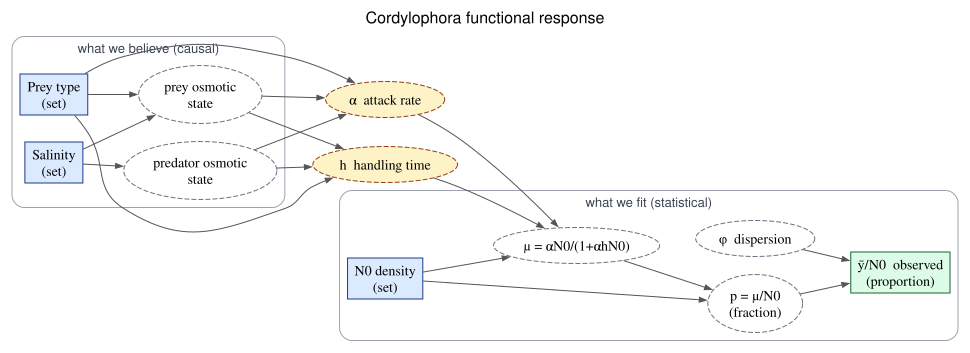

In [36]:
two_panel_dag("M2")   # preview of the planned bounded-support measurement layer

In [37]:
two_panel_dag("M2").render(FIG_DIR/'m2_dag', format="png", cleanup=True)

'/Users/erdemkarakoylu/projex/replications/nandini_et_al/figures/m2_dag.png'

In [38]:
fr_model_m2 = build_model_m2(
    coords=coords, N0=N0, ybar=ybar, se=se, prey_idx=prey_idx, sal_idx=sal_idx
)

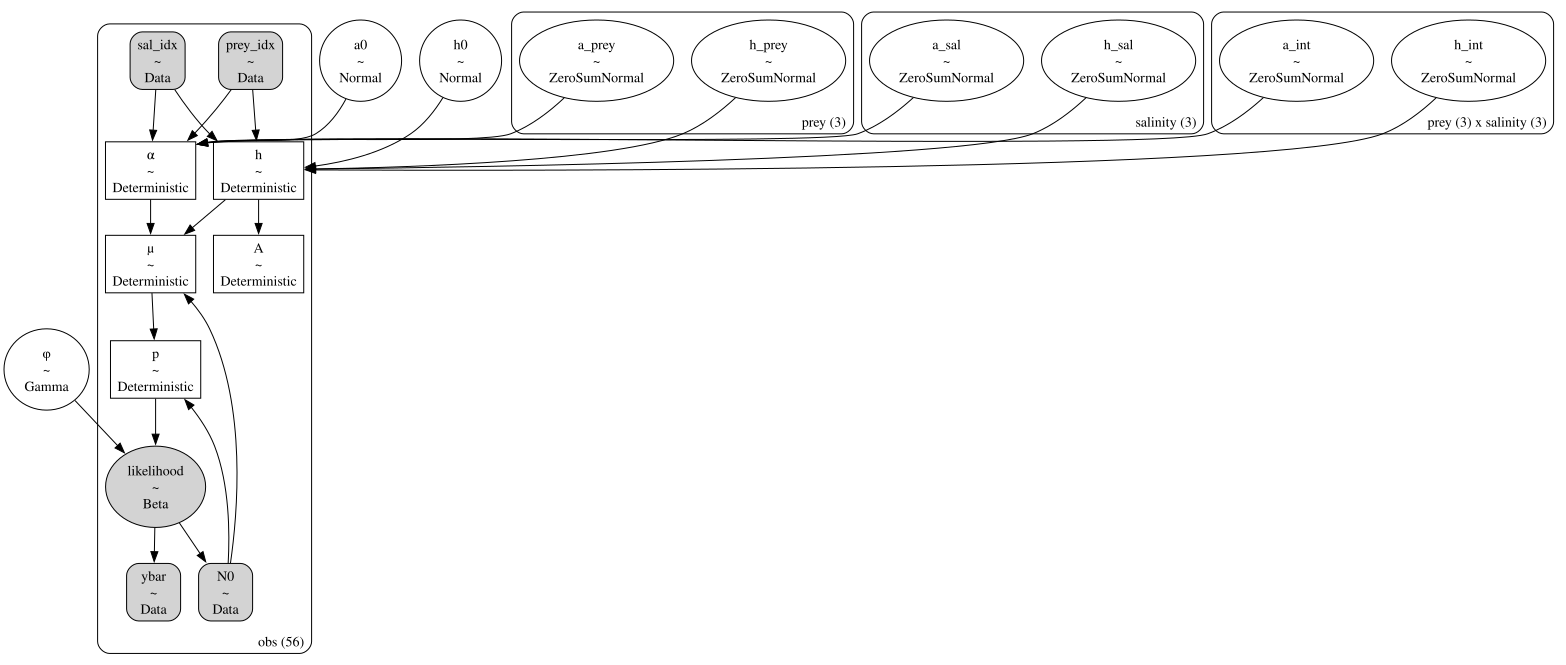

In [39]:
fr_model_m2.to_graphviz()

In [40]:
fr_model_m2.debug()

point={'a0': array(0.), 'a_prey_zerosum__': array([0., 0.]), 'a_sal_zerosum__': array([0., 0.]), 'a_int_zerosum__': array([[0., 0.],
       [0., 0.]]), 'h0': array(-3.68887945), 'h_prey_zerosum__': array([0., 0.]), 'h_sal_zerosum__': array([0., 0.]), 'h_int_zerosum__': array([[0., 0.],
       [0., 0.]]), 'φ_log__': array(2.99573227)}

No problems found


In [41]:
with fr_model_m2:
    idata2 = pm.sample_prior_predictive()

pp2 = idata2.prior_predictive["likelihood"]  # fraction scale, (chain, draw, obs)
print("prior predictive fraction range:", float(pp2.min()), float(pp2.max()))
print("always in (0,1):", bool((pp2 > 0).all() and (pp2 < 1).all()))

# implied asymptote/attack-rate sanity, same as M1's check
A2 = idata2.prior["A"]
a2 = idata2.prior["\u03b1"]
print("A (1/h) quantiles 1/50/99:", np.round(A2.quantile([.01,.5,.99]).values, 1))
print("\u03b1 quantiles 1/50/99:", np.round(a2.quantile([.01,.5,.99]).values, 3))

Sampling: [a0, a_int, a_prey, a_sal, h0, h_int, h_prey, h_sal, likelihood, φ]


prior predictive fraction range: 1.487821695253653e-72 0.9999999999990548
always in (0,1): True
A (1/h) quantiles 1/50/99: [  5.3  39.3 342.2]
α quantiles 1/50/99: [0.017 0.493 0.982]


In [42]:
with fr_model_m2:
    idata2.update(pm.sample(draws=2000, tune=1000, chains=4, cores=1, progressbar=False))

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_54687/2567887443.py:2: UserWarning: pymc requires nutpie>=0.16.10. Falling back to the pymc NUTS sampler. Upgrade with `pip install -U nutpie` or `conda install -c conda-forge 'nutpie>=0.16.10'`.
  idata2.update(pm.sample(draws=2000, tune=1000, chains=4, cores=1, progressbar=False))
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [a0, a_prey, a_sal, a_int, h0, h_prey, h_sal, h_int, φ]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.


In [43]:
with fr_model_m2:
    idata2.update(pm.sample_posterior_predictive(idata2))

Sampling: [likelihood]


Output()

In [44]:
ok, diag = azs.diagnose(idata2, return_diagnostics=True, show_diagnostics=False)
print(ok)
print(diag)

False
{'divergent': {'n_divergent': 0, 'pct': np.float64(0.0), 'total_samples': np.int64(8000)}, 'treedepth': {'n_max': 0, 'pct': np.float64(0.0), 'total_samples': np.int64(8000)}, 'bfmi': {'bfmi_values': array([0.99004402, 0.94927971, 1.03914989, 1.03589692]), 'failed_chains': [], 'threshold': 0.3}, 'ess': {'bad_params': [], 'ess_values': <xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*, 'threshold_ratio': 0.001, 'total_samples': np.int64(8000)}, 'rhat': {'bad_params': [], 'rhat_values': <xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*, 'threshold': 1.01}}


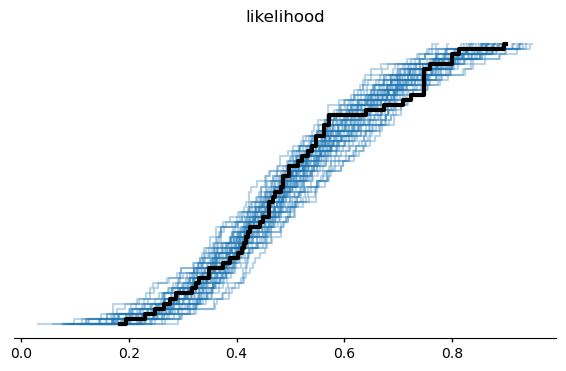

In [45]:
pc = azp.plot_ppc_dist(
    idata2, group="posterior_predictive",
    visuals={"observed_dist": {"linewidth": 3}},
    figure_kwargs={"figsize": (7, 4)},
)
pc.savefig(FIG_DIR / "ppc_m2.png", dpi=300, bbox_inches="tight")

In [46]:
print("fraction scale:", summarize_ppc(idata2))

# count-scale rescale, for direct comparison with M1's PPC numbers
idata2_counts = idata2.copy()
N0_da = idata2.constant_data["N0"]
idata2_counts["posterior_predictive"]["likelihood"] = idata2.posterior_predictive["likelihood"] * N0_da
idata2_counts["observed_data"]["likelihood"] = idata2.observed_data["likelihood"] * N0_da
print("count scale:", summarize_ppc(idata2_counts))

fraction scale: {'coverage': 0.9821428571428571, 'prob': 0.94, 'mean_abs_error': 0.0752063869333829, 'mean_signed_error': -0.0013670921039878083}
count scale: {'coverage': 0.9821428571428571, 'prob': 0.94, 'mean_abs_error': 2.29337470389994, 'mean_signed_error': -0.16793490732082333}


## Model comparison: M1 vs M2 (LOO-CV)

M1's likelihood is over the raw count `ȳ`; M2's is over the rescaled proportion
`ȳ/N0`. These are different random variables, related by a per-observation rescaling
that varies across cells -- so their `elpd_loo` values are not directly comparable
without a change-of-variables correction first.

If `z = ȳ/N0`, then `dz/dȳ = 1/N0`, so `log f_ȳ(ȳ) = log f_Beta(z) + log|dz/dȳ|
= log f_Beta(z) - log(N0)`. `arviz_stats.loo`'s `log_jacobian` argument applies exactly
this correction internally, putting both models' `elpd_loo` on the same footing: the
density of the actually-observed count, not two different quantities that happen to
look comparable. Each model's own `loo()` call also reports its Pareto-k table, the
diagnostic for whether PSIS itself is trustworthy at each observation.

In [47]:
# M1's log_likelihood was already computed above (Prior sensitivity: power-scaling
# check) for psense; recomputing it here would just overwrite it with the same values.
with fr_model_m2:
    pm.compute_log_likelihood(idata2, model=fr_model_m2)


Output()

In [48]:
log_jac = -np.log(idata2.constant_data["N0"])
loo1 = azs.loo(idata, pointwise=True)
loo2 = azs.loo(idata2, pointwise=True, log_jacobian=log_jac)

print(loo1)
print(loo2)

comparison = azs.compare({"M1": loo1, "M2": loo2})
comparison

/Users/erdemkarakoylu/miniconda3/envs/causal_marine/lib/python3.13/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 56 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -151.40     9.37
p_loo       17.57        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       53   94.6%
   (0.70, 1]   (bad)         1    1.8%
    (1, Inf)   (very bad)    2    3.6%

Computed from 8000 posterior samples and 56 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -134.53     8.03
p_loo        9.88        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       56  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%



,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
M2,0,0.0,0.0,NaN,,,9.9,-130.0,8.0,1.0
M1,1,-20.0,5.5,1.0,N < 100,3 k̂ > 0.70,17.6,-150.0,9.4,0.0
